# Customer Churn Prediction — IBM Telco Customer Dataset

## Introduction

In this project, I use the **IBM Telco Customer Churn dataset** to explore customer characteristics and identify patterns associated with churn. The analysis combines **Exploratory Data Analysis (EDA)** with **machine learning** to understand the factors that may be related to customer churn and to build predictive models.

The project Contains:

1. **Understanding Data & Cleaning** 
2. **Exploratory Data Analysis** 
3. **Feature Analysis & Selection** 
4. **Data Preprocessing** 
5. **Model Development** 
6. **Model Evaluation**
7. **Model and Parameter Tuning**
8. **Feature Importance**
9. **Model Monitoring**

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [2]:
pd.set_option('display.max_columns', None)

# Understanding Data & Cleaning

In [3]:
df = pd.read_excel('../data/Telco_customer_churn.xlsx')
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df[df['CustomerID'] == '7590-VHVEG']

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
1869,7590-VHVEG,1,United States,California,Los Angeles,90001,"33.973616, -118.24902",33.973616,-118.24902,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,27,3964,NaN


In [5]:
df.shape

(7043, 33)

In [6]:
df.dtypes

CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges         object
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason             str
dtype: object

In [7]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df.dtypes

CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges        float64
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason             str
dtype: object

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [9]:
df.isna().sum().sort_values(ascending=False)

Churn Reason         5174
Total Charges          11
CustomerID              0
Count                   0
Country                 0
Zip Code                0
Lat Long                0
State                   0
City                    0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Latitude                0
Longitude               0
Internet Service        0
Multiple Lines          0
Online Security         0
Online Backup           0
Streaming TV            0
Streaming Movies        0
Device Protection       0
Tech Support            0
Paperless Billing       0
Contract                0
Monthly Charges         0
Payment Method          0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
dtype: int64

In [10]:
eda_summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isna().sum(),
    "missing_%": df.isna().mean() * 100,
    "unique": df.nunique()
})

eda_summary

,dtype,missing,missing_%,unique
CustomerID,str,0,0.000000,7043
Count,int64,0,0.000000,1
Country,str,0,0.000000,1
State,str,0,0.000000,1
City,str,0,0.000000,1129
Zip Code,int64,0,0.000000,1652
Lat Long,str,0,0.000000,1652
Latitude,float64,0,0.000000,1652
Longitude,float64,0,0.000000,1651
Gender,str,0,0.000000,2


In [11]:
df[df['Total Charges'].isna()]
# The resulting table indicates that the missing values in Total Charges correspond to customers with a tenure of zero months. 
# Therefore, these missing values can reasonably be replaced with 0, as customers with zero months of tenure have not yet accumulated any charges

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,No,Yes,No,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0,36,2578,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,No,No,No,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No,0,68,5504,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,No,Yes,No,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No,0,45,2048,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No,0,48,4950,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,No,Yes,No,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No,0,30,4740,NaN
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No,0,53,2019,NaN
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No,0,49,2299,NaN
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No,0,27,3763,NaN
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No,0,69,4890,NaN
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No,0,44,2342,NaN


In [12]:
df['Total Charges'] = df['Total Charges'].fillna(0)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
#check for invalid values 
df.nunique()

CustomerID           7043
Count                   1
Country                 1
State                   1
City                 1129
Zip Code             1652
Lat Long             1652
Latitude             1652
Longitude            1651
Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Tenure Months          73
Phone Service           2
Multiple Lines          3
Internet Service        3
Online Security         3
Online Backup           3
Device Protection       3
Tech Support            3
Streaming TV            3
Streaming Movies        3
Contract                3
Paperless Billing       2
Payment Method          4
Monthly Charges      1585
Total Charges        6531
Churn Label             2
Churn Value             2
Churn Score            85
CLTV                 3438
Churn Reason           20
dtype: int64

In [15]:
# Invalid Tenure months,
df[df["Tenure Months"] < 0]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason


In [16]:
# Invalid Monthly Charges 
df[df["Monthly Charges"] < 0]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason


In [17]:
#Invalid Total Charges 
df[df['Total Charges'] < 0]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason


In [18]:
#check invalid values for relevant categorical columns
drop_col = ["CustomerID","Count","Country","State", "City", "Zip Code","Lat Long", "Latitude","Longitude","Tenure Months", "Monthly Charges","Total Charges", "Churn Score", "CLTV","Churn Reason"]
df_category = df.drop(columns=drop_col)
for col in df_category.columns:
  print(f'Unique Values in {col}')
  print(list(df_category[col].unique()))

Unique Values in Gender
['Male', 'Female']
Unique Values in Senior Citizen
['No', 'Yes']
Unique Values in Partner
['No', 'Yes']
Unique Values in Dependents
['No', 'Yes']
Unique Values in Phone Service
['Yes', 'No']
Unique Values in Multiple Lines
['No', 'Yes', 'No phone service']
Unique Values in Internet Service
['DSL', 'Fiber optic', 'No']
Unique Values in Online Security
['Yes', 'No', 'No internet service']
Unique Values in Online Backup
['Yes', 'No', 'No internet service']
Unique Values in Device Protection
['No', 'Yes', 'No internet service']
Unique Values in Tech Support
['No', 'Yes', 'No internet service']
Unique Values in Streaming TV
['No', 'Yes', 'No internet service']
Unique Values in Streaming Movies
['No', 'Yes', 'No internet service']
Unique Values in Contract
['Month-to-month', 'Two year', 'One year']
Unique Values in Paperless Billing
['Yes', 'No']
Unique Values in Payment Method
['Mailed check', 'Electronic check', 'Bank transfer (automatic)', 'Credit card (automatic)'

In [19]:
df['Churn Reason'].value_counts()

Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Service dissatisfaction                       89
Lack of self-service on Website               88
Extra data charges                            57
Moved                                         53
Limited range of services                     44
Lack of affordable download/upload speed      44
Long distance charges                         44
Poor expertise of phone support               20
Poor expertise of online support              19
Deceased                                       6
Name: c

# Exploratory Data Analysis

<Axes: ylabel='Churn Reason'>

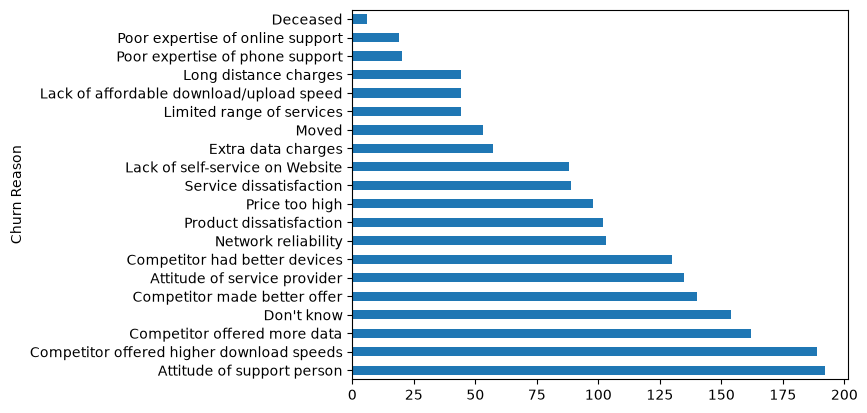

In [20]:
#let's check the reasons as to why customer churn. This might help us select features for model training and prediction 
df['Churn Reason'].value_counts().plot(kind='barh')

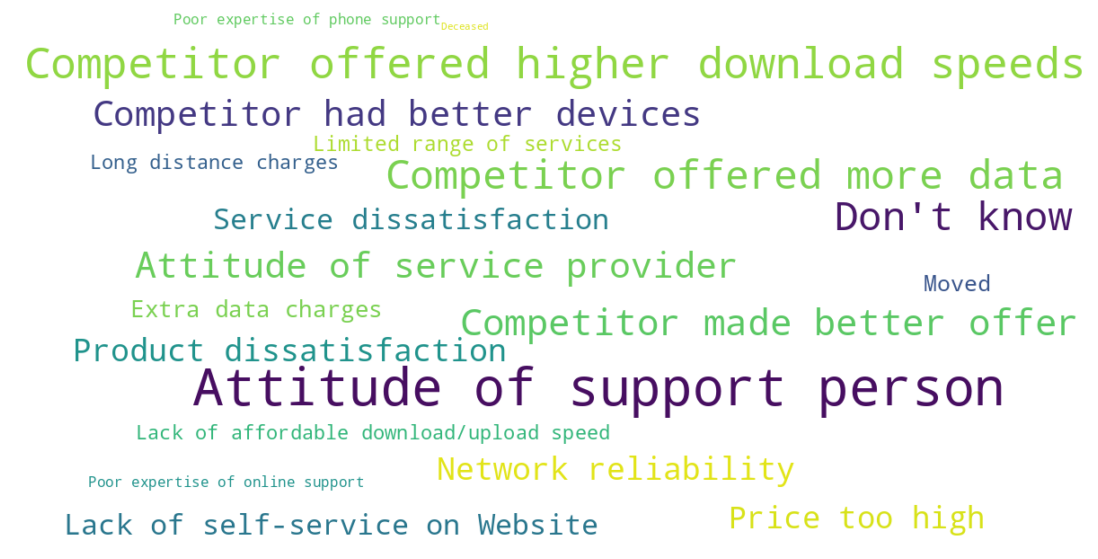

In [21]:
#let's visualize it using word buble
from wordcloud import WordCloud
churn_reasons = df['Churn Reason'].value_counts().to_dict()
word_cloud = WordCloud(
  height=600,
  width=1200,
  background_color='white'
).generate_from_frequencies(churn_reasons)
plt.figure(figsize=(14, 7))
plt.imshow(word_cloud, interpolation="bilinear")
plt.axis('off')
plt.show()

In [22]:
#let's save the cleaned data for later use
df.to_excel('../data/cleaned_Telco_consumer_churn.xlsx')

In [23]:
# We can now examine the features associated with customer churn, 
# using the reported churn reasons as a basis for identifying potentially influential factors
features = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Tenure Months",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method",
    "Monthly Charges",
    "Total Charges",
]
target = 'Churn Value'


In [24]:
numeric_features = list(df[features].select_dtypes(include=['int64','float64']).columns)
numeric_features

['Tenure Months', 'Monthly Charges', 'Total Charges']

In [25]:
categorical_features = list(df[features].select_dtypes(include=['str']).columns)
categorical_features

['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method']

In [26]:
#lets check if the target / Churn Value is balanced 
df[target].value_counts(normalize=True) * 100

Churn Value
0    73.463013
1    26.536987
Name: proportion, dtype: float64

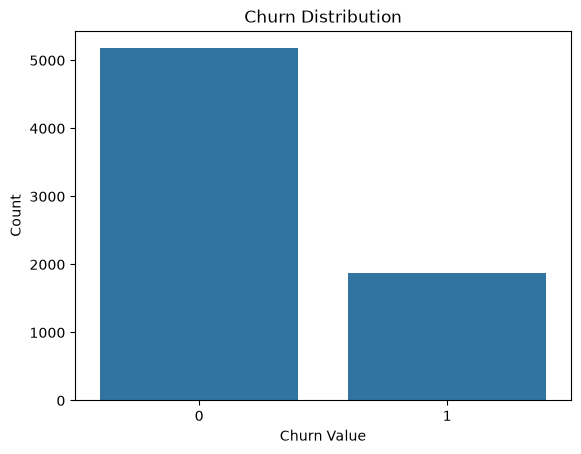

In [27]:
sns.countplot(data=df, x='Churn Value')
plt.title('Churn Distribution')
plt.ylabel('Count')
plt.show()

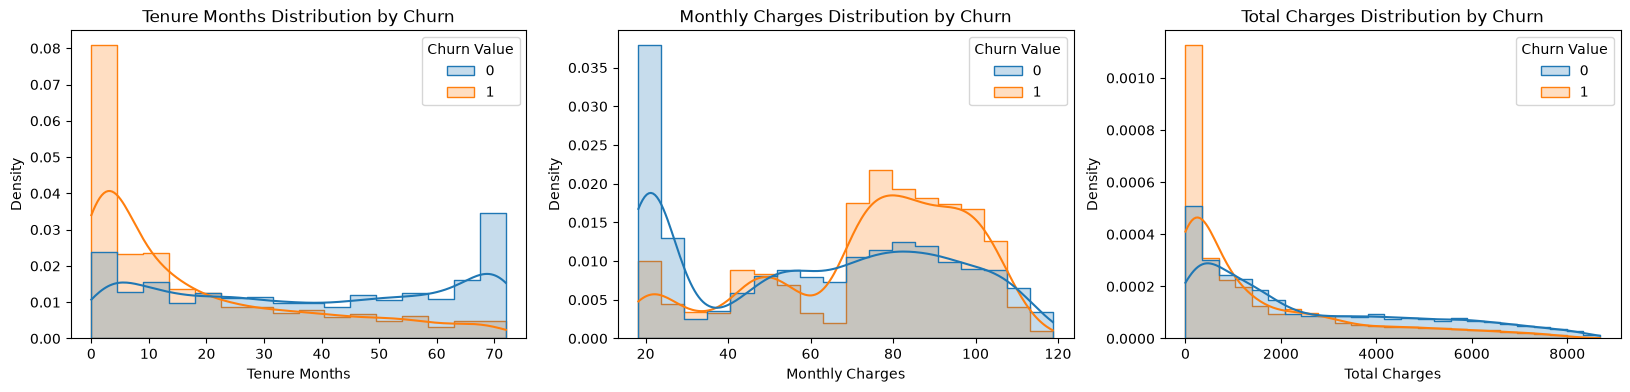

In [28]:
# let's see feature distribution by Churn 
plt.figure(figsize=(20,4))
for i,feature in enumerate(numeric_features):
  plt.subplot(int(len(numeric_features)/3),3,i+1)
  sns.histplot(
    data=df, 
    x=feature, 
    hue='Churn Value', 
    kde=True, 
    element='step',
    stat='density',
    common_norm=False
  )
  plt.title(f"{feature} Distribution by Churn")
plt.show()


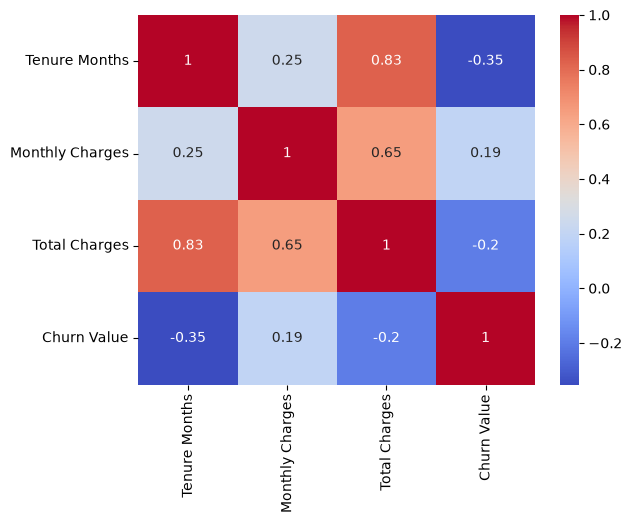

In [29]:
#let's see the correlation between the numeric features and churn 
corr_ele = numeric_features + ['Churn Value']
corr = df[corr_ele].corr()
sns.heatmap(data=corr, annot=True, cmap='coolwarm')
plt.show()

In [30]:
len(categorical_features)

16

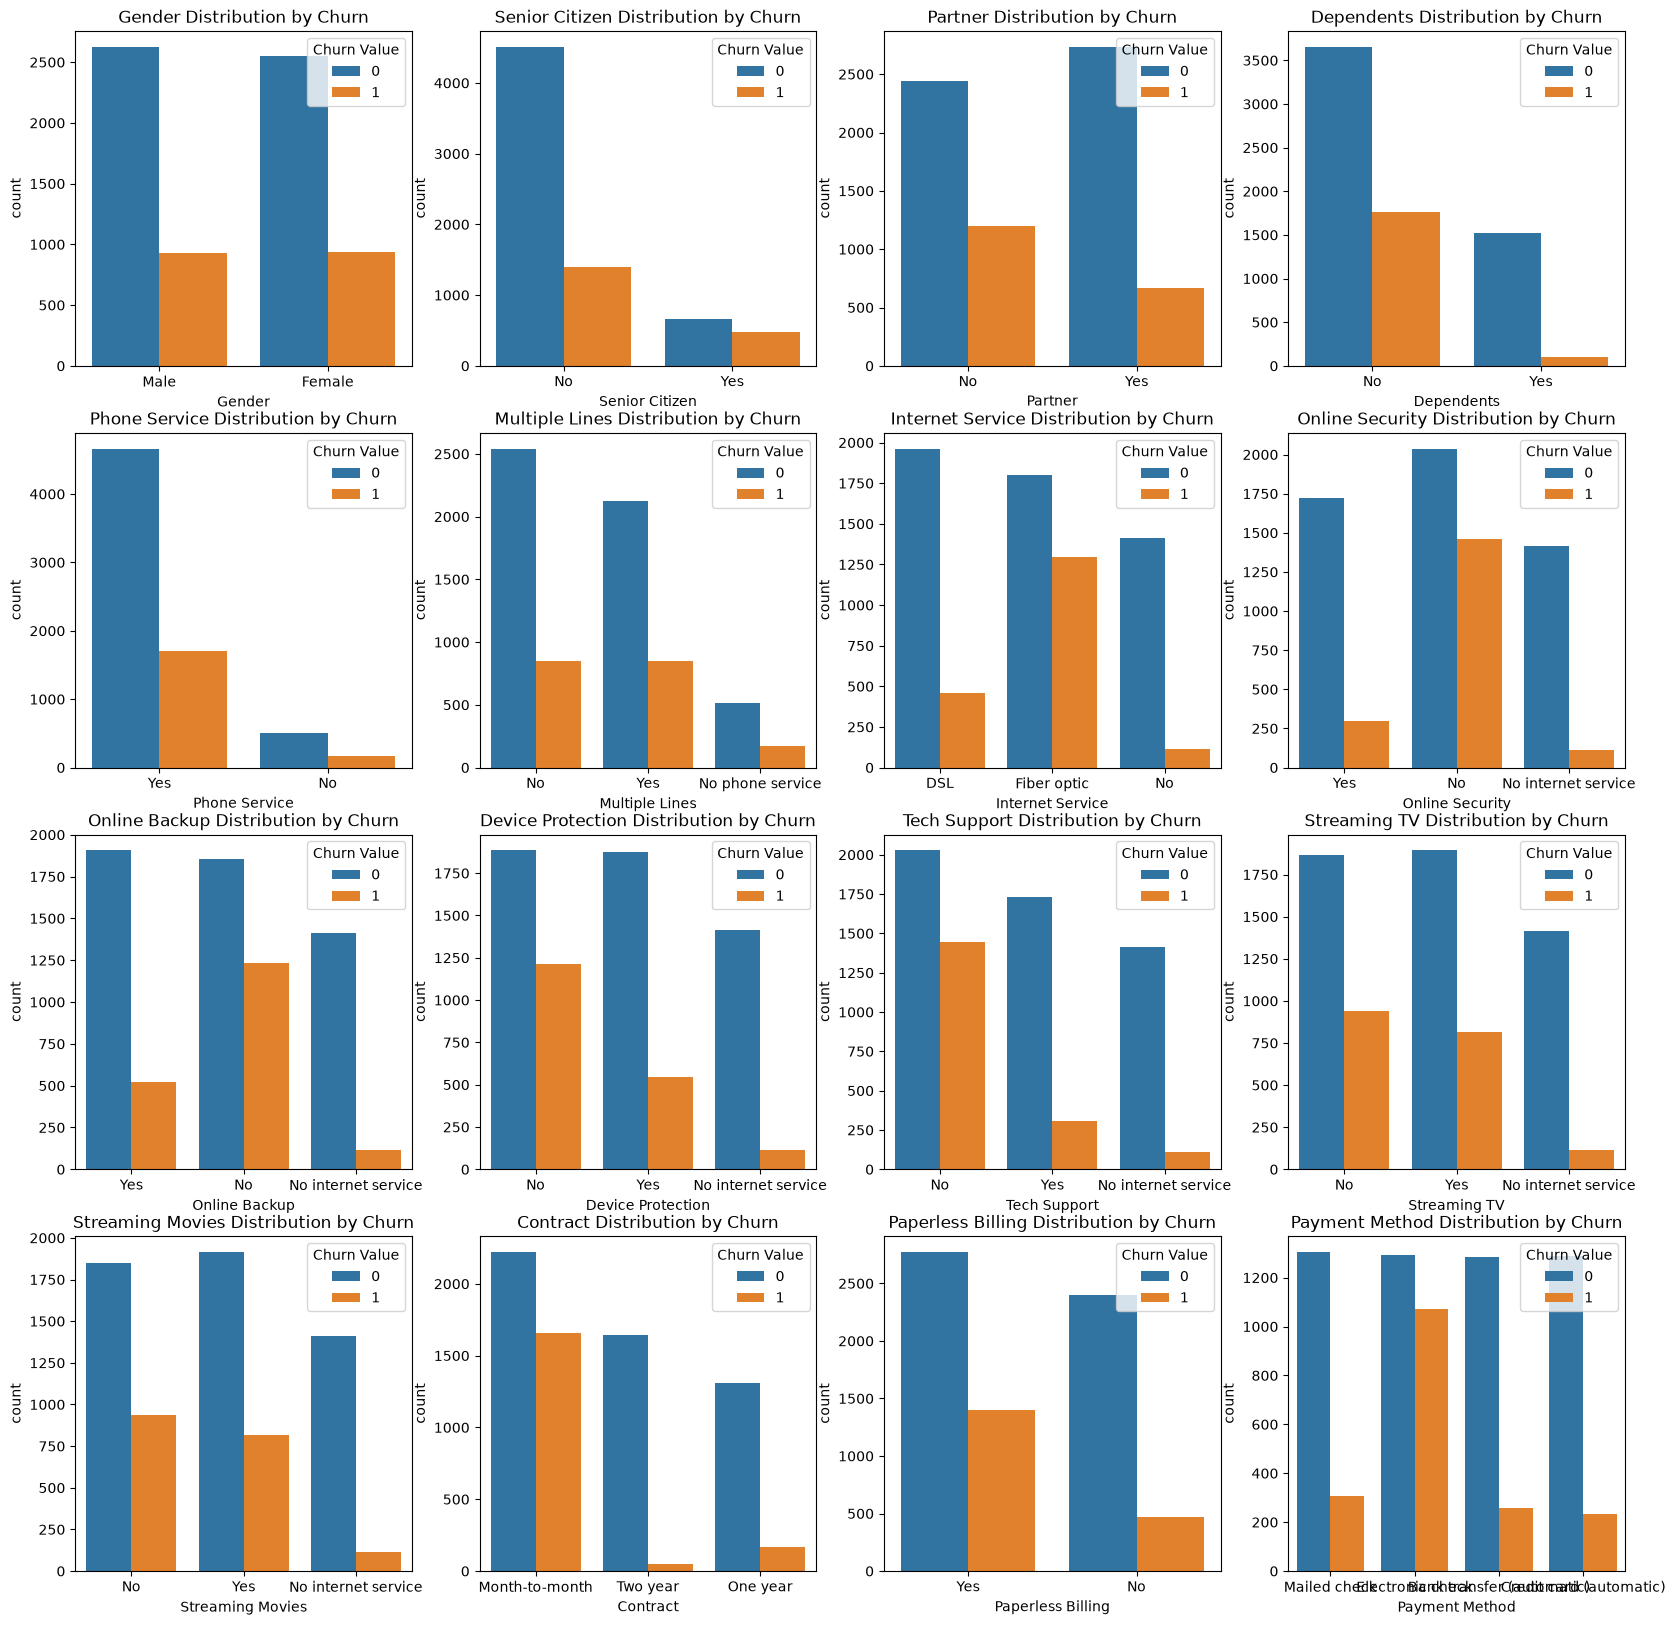

In [31]:
plt.figure(figsize=(20,20))
for i,feature in enumerate(categorical_features): 
  plt.subplot(int(len(categorical_features)/4),4,i+1)
  sns.countplot(
    data=df, 
    x=feature, 
    hue='Churn Value', 
  )
  plt.title(f"{feature} Distribution by Churn")
  #plt.xticks(rotation=75)
plt.show()

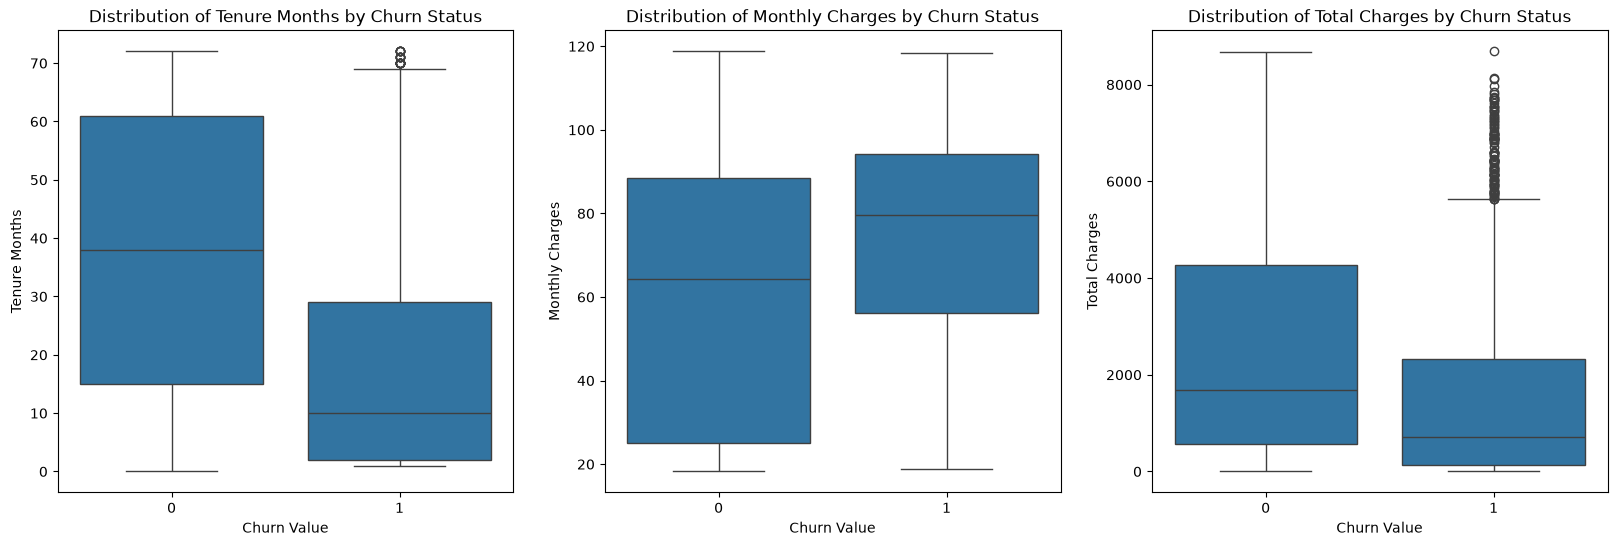

In [32]:
#let's see if there is a single feature 
plt.figure(figsize=(20,6))
for i, feature in enumerate(numeric_features): 
  plt.subplot(1,3,i+1)
  sns.boxplot(data=df, x='Churn Value', y=feature)
  plt.title(f'Distribution of {feature} by Churn Status')
plt.show()

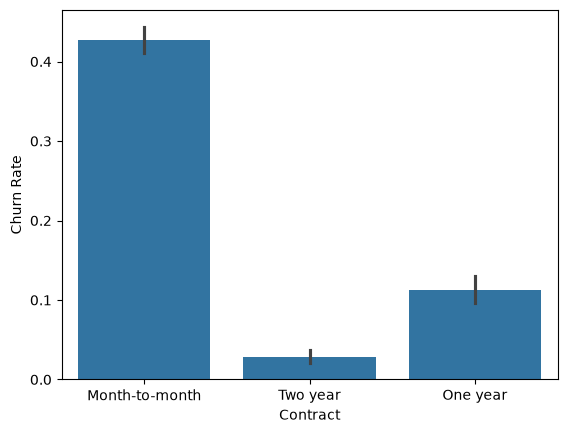

In [33]:
sns.barplot(
    data=df,
    x="Contract",
    y="Churn Value"
)

plt.ylabel("Churn Rate")
plt.show()

# Feature Analysis & Selection

In [34]:
len(features)

19

In [35]:
#lets see churn rate by feature 
for feature in features: 
    churn_rate = df.groupby(feature)["Churn Value"].mean().sort_values(ascending=False).reset_index()
    churn_rate["Churn Value"] *= 100
    print(churn_rate)

   Gender  Churn Value
0  Female    26.920872
1    Male    26.160338
  Senior Citizen  Churn Value
0            Yes    41.681261
1             No    23.606168
  Partner  Churn Value
0      No    32.957979
1     Yes    19.664903
  Dependents  Churn Value
0         No    32.551699
1        Yes     6.515058
    Tenure Months  Churn Value
0               1    61.990212
1               2    51.680672
2               5    48.120301
3               4    47.159091
4               3    47.000000
..            ...          ...
68             63     5.555556
69             64     5.000000
70             71     3.529412
71             72     1.657459
72              0     0.000000

[73 rows x 2 columns]
  Phone Service  Churn Value
0           Yes    26.709637
1            No    24.926686
     Multiple Lines  Churn Value
0               Yes    28.609896
1                No    25.044248
2  No phone service    24.926686
  Internet Service  Churn Value
0      Fiber optic    41.892765
1              D

In [36]:
# From the results above, Gender seems to be the least contributing factor, 
# Regardless, we will train two models. One model taking Gender as part of one of the features and a second model without it and compare 
# the resulting models based on recall and precision
from scipy.stats import chi2_contingency

gender_churn = pd.crosstab(df["Gender"], df["Churn Value"])

chi2, p_value, dof, expected = chi2_contingency(gender_churn)

print("Chi-square:", chi2)
print("p-value:", p_value)

Chi-square: 0.4840828822091383
p-value: 0.48657873605618596


# Data Preprocessing 

In [37]:
numeric_features

['Tenure Months', 'Monthly Charges', 'Total Charges']

In [38]:
X = df[features]
y = df[target]

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

In [40]:
X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, test_size=0.3, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=0.5, stratify=y_val_test)

In [41]:
y_train.mean(), y_val_test.mean()

(np.float64(0.2653144016227181), np.float64(0.26549929010885))

In [42]:
y_val.mean(), y_test.mean()

(np.float64(0.26515151515151514), np.float64(0.26584673604541154))

# Model Development

In [43]:
preprocessor = ColumnTransformer(transformers=[
  ('numeric', StandardScaler(), numeric_features), 
  ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])
model = DecisionTreeClassifier(
   criterion='gini', 
   max_depth=5, 
   min_samples_split=20, 
   min_samples_leaf=15, 
   max_features=None,
   class_weight='balanced', 
   random_state=42,
    )
pipeline = Pipeline([
  ('preprocessor', preprocessor),
  ('model', model)
  ])

In [44]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Gender','Senior Citizen','Partner',...,'Payment Method', 'Monthly Charges','Total Charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

In [45]:
y_pred = pipeline.predict(X_val)

In [46]:
from sklearn.metrics import classification_report

In [47]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.72      0.81       776
           1       0.52      0.82      0.63       280

    accuracy                           0.75      1056
   macro avg       0.72      0.77      0.72      1056
weighted avg       0.81      0.75      0.76      1056



In [48]:
y_train_pred = pipeline.predict(X_train)
y_val_pred = pipeline.predict(X_val)

print("TRAINING")
print(classification_report(y_train, y_train_pred))

print("VALIDATION")
print(classification_report(y_val, y_val_pred))

TRAINING
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      3622
           1       0.54      0.83      0.65      1308

    accuracy                           0.77      4930
   macro avg       0.73      0.79      0.74      4930
weighted avg       0.82      0.77      0.78      4930

VALIDATION
              precision    recall  f1-score   support

           0       0.92      0.72      0.81       776
           1       0.52      0.82      0.63       280

    accuracy                           0.75      1056
   macro avg       0.72      0.77      0.72      1056
weighted avg       0.81      0.75      0.76      1056



In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)

print(cm)

[[561 215]
 [ 51 229]]


# Model Evaluation 

In [50]:
y_test_pred = pipeline.predict(X_test)

print("Test")
print(classification_report(y_test, y_test_pred))


Test
              precision    recall  f1-score   support

           0       0.90      0.72      0.80       776
           1       0.50      0.78      0.61       281

    accuracy                           0.74      1057
   macro avg       0.70      0.75      0.70      1057
weighted avg       0.79      0.74      0.75      1057



# Model and Parameter Tuning 

In [51]:
from sklearn.model_selection import GridSearchCV

In [52]:
print(pipeline.get_params().keys())

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessor', 'model', 'preprocessor__n_jobs', 'preprocessor__remainder', 'preprocessor__sparse_threshold', 'preprocessor__transformer_weights', 'preprocessor__transformers', 'preprocessor__verbose', 'preprocessor__verbose_feature_names_out', 'preprocessor__numeric', 'preprocessor__categorical', 'preprocessor__numeric__copy', 'preprocessor__numeric__with_mean', 'preprocessor__numeric__with_std', 'preprocessor__categorical__categories', 'preprocessor__categorical__drop', 'preprocessor__categorical__dtype', 'preprocessor__categorical__feature_name_combiner', 'preprocessor__categorical__handle_unknown', 'preprocessor__categorical__max_categories', 'preprocessor__categorical__min_frequency', 'preprocessor__categorical__sparse_output', 'model__ccp_alpha', 'model__class_weight', 'model__criterion', 'model__max_depth', 'model__max_features', 'model__max_leaf_nodes', 'model__min_impurity_decrease', 'model__min_samples_leaf', 'model_

In [53]:
par_grid = {
  "model__criterion": ['gini', 'entropy'],
  "model__max_depth": [3,5,6,7,8,9], 
  "model__min_samples_split": [20,30,40,50], 
  "model__min_samples_leaf": [10,15,20,25,30], 
  "model__max_features":[None], 
  "model__class_weight": [None, 'balanced']
}

In [54]:
print(pipeline)
print(pipeline.get_params().keys())

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Senior Citizen',
                                                   'Partner', 'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Online Security',
                                                   'Online Backup',
                        

In [55]:
grid_search = GridSearchCV(estimator=pipeline, param_grid=par_grid, scoring='f1', cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 480 candidates, totalling 2400 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': [None, 'balanced'], 'model__criterion': ['gini', 'entropy'], 'model__max_depth': [3, 5, ...], 'model__max_features': [None], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.

In [56]:
grid_search.best_score_

np.float64(0.6284316541668533)

In [57]:
grid_search.best_params_

{'model__class_weight': 'balanced',
 'model__criterion': 'entropy',
 'model__max_depth': 9,
 'model__max_features': None,
 'model__min_samples_leaf': 20,
 'model__min_samples_split': 20}

In [58]:
model = grid_search.best_estimator_

In [59]:
y_pred = model.predict(X_val)

In [60]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.70      0.79       776
           1       0.49      0.80      0.61       280

    accuracy                           0.73      1056
   macro avg       0.70      0.75      0.70      1056
weighted avg       0.80      0.73      0.74      1056



In [61]:
y_pred_test = model.predict(X_test)
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.87      0.72      0.79       776
           1       0.47      0.70      0.56       281

    accuracy                           0.71      1057
   macro avg       0.67      0.71      0.68      1057
weighted avg       0.76      0.71      0.73      1057



The tuned Decision Tree achieved 0.66 F1 on the held-out test set for the churn class, with 0.89 recall and 0.52 precision. 
The model therefore identifies most actual churners, while generating a relatively high number of false positives

In [81]:
cm = confusion_matrix(y_test, y_pred_test)
cm.tolist()

[[559, 217], [85, 196]]

In [63]:
cv_results = grid_search.cv_results_
best_index = grid_search.best_index_

print(cv_results["split0_test_score"][best_index])
print(cv_results["split1_test_score"][best_index])
print(cv_results["split2_test_score"][best_index])
print(cv_results["split3_test_score"][best_index])
print(cv_results["split4_test_score"][best_index])

0.6289120715350224
0.6283987915407855
0.6477987421383647
0.6153846153846154
0.6216640502354788


In [64]:
from sklearn.metrics import precision_recall_curve
y_test_prob = model.predict_proba(X_test)[:,1]
precision, recall, threshold = precision_recall_curve(y_test, y_test_prob)
df_roc = pd.DataFrame({
  "threshold":threshold, 
  "precision": precision[:-1], 
  "recall": recall[:-1], 
})
df_roc['f1'] = 2 * (df_roc['precision'] * df_roc['recall']) / (df_roc['precision'] + df_roc['recall'])
df_roc

,threshold,precision,recall,f1
0,0.000000,0.265847,1.000000,0.420030
1,0.077416,0.359459,0.946619,0.521058
2,0.096253,0.363885,0.946619,0.525692
3,0.111797,0.380544,0.946619,0.542857
4,0.116500,0.381636,0.946619,0.543967
...,...,...,...,...
84,0.935062,0.911765,0.110320,0.196825
85,0.943229,0.965517,0.099644,0.180645
86,0.946056,0.964286,0.096085,0.174757
87,0.958063,0.961538,0.088968,0.162866


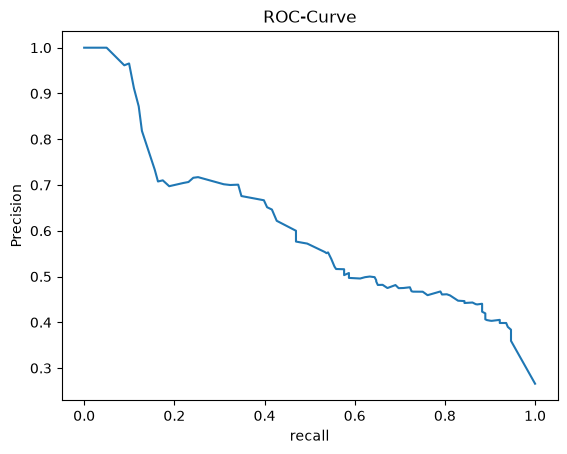

In [65]:
plt.plot(recall, precision)
plt.title('ROC-Curve')
plt.xlabel('recall')
plt.ylabel('Precision')
plt.show()

## Feature importance

In [66]:
tree_model = model.named_steps['model']
feature_values = tree_model.feature_importances_
tree_model_feature_names = model.named_steps['preprocessor'].get_feature_names_out()
feature_importance = pd.DataFrame({
  "names": tree_model_feature_names, 
  "value (%)": feature_values * 100
})
feature_importance['names']=feature_importance['names'].astype(str).str.replace('numeric__','').str.replace('categorical__','')
print(feature_importance)

                                       names     value (%)
0                              Tenure Months  1.147230e+01
1                            Monthly Charges  1.168258e+01
2                              Total Charges  4.071921e+00
3                              Gender_Female  7.331974e-01
4                                Gender_Male  2.066292e-01
5                          Senior Citizen_No  1.844671e-01
6                         Senior Citizen_Yes  3.780753e-01
7                                 Partner_No  3.131696e-01
8                                Partner_Yes  5.556173e-01
9                              Dependents_No  7.779530e+00
10                            Dependents_Yes  2.143037e+00
11                          Phone Service_No  0.000000e+00
12                         Phone Service_Yes  9.285506e-01
13                         Multiple Lines_No  2.257861e-01
14           Multiple Lines_No phone service  1.387121e-01
15                        Multiple Lines_Yes  6.296146e-

In [67]:
import shap

In [68]:
preprocessor = pipeline.named_steps['preprocessor']
x_train_trans = preprocessor.transform(X_train)
x_test_trans = preprocessor.transform(X_test)
x_train_trans.shape, X_train.shape, x_test_trans.shape, X_test.shape

((4930, 46), (4930, 19), (1057, 46), (1057, 19))

In [69]:
explaliner = shap.TreeExplainer(tree_model)
shap_values = explaliner.shap_values(x_test_trans)
shap_values_churn = shap_values[:,:,1]
shap_values_churn.shape

(1057, 46)

In [70]:
shap_df = pd.DataFrame(
    shap_values_churn,
    columns=feature_importance['names'],
    index=X_test.index
)

shap_df.head()

names,Tenure Months,Monthly Charges,Total Charges,Gender_Female,Gender_Male,Senior Citizen_No,Senior Citizen_Yes,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,Phone Service_No,Phone Service_Yes,Multiple Lines_No,Multiple Lines_No phone service,Multiple Lines_Yes,Internet Service_DSL,Internet Service_Fiber optic,Internet Service_No,Online Security_No,Online Security_No internet service,Online Security_Yes,Online Backup_No,Online Backup_No internet service,Online Backup_Yes,Device Protection_No,Device Protection_No internet service,Device Protection_Yes,Tech Support_No,Tech Support_No internet service,Tech Support_Yes,Streaming TV_No,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,Paperless Billing_No,Paperless Billing_Yes,Payment Method_Bank transfer (automatic),Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
3743,-0.086736,0.020028,-0.015148,0.003615,-0.001784,-0.008754,0.005456,-0.000864,0.003772,0.035078,0.003244,0.0,-0.010010,0.001124,-0.000379,0.002860,0.0,-0.062762,0.0,-0.007203,0.0,-0.003939,-0.003667,0.0,0.0,0.000373,0.0,0.0,-0.014160,0.0,0.0,0.0,0.0,0.002020,-0.001747,0.0,0.021506,-0.142272,-0.014561,-0.087901,-0.002016,0.004253,0.0,0.0,-0.012137,-0.000086
1647,0.123587,-0.029688,0.113951,0.009475,-0.002198,-0.003367,0.015653,0.004431,-0.005066,0.012926,0.006086,0.0,-0.002858,-0.001809,-0.000767,-0.012576,0.0,0.056557,0.0,0.001320,0.0,0.001203,-0.004163,0.0,0.0,-0.000299,0.0,0.0,0.014910,0.0,0.0,0.0,0.0,-0.000905,0.002236,0.0,0.003234,0.198953,-0.003756,0.011339,-0.001362,0.005123,0.0,0.0,-0.012920,0.000748
4294,0.010839,0.119008,-0.019184,-0.002639,0.003920,0.021814,-0.000777,-0.000351,0.000622,0.076408,0.007543,0.0,-0.004471,-0.001658,-0.000498,-0.001987,0.0,0.049641,0.0,0.000981,0.0,0.002476,-0.002607,0.0,0.0,-0.000642,0.0,0.0,0.006776,0.0,0.0,0.0,0.0,0.002020,-0.000593,0.0,0.007779,-0.246150,-0.010518,-0.013012,0.002292,0.031193,0.0,0.0,0.029331,-0.000143
3401,-0.021509,-0.044342,-0.003742,0.002530,-0.001062,0.001422,-0.000852,0.000119,-0.000792,0.027255,0.003131,0.0,0.040495,0.000649,0.000438,-0.001982,0.0,-0.029560,0.0,0.005508,0.0,0.000710,-0.000309,0.0,0.0,0.000376,0.0,0.0,-0.013781,0.0,0.0,0.0,0.0,-0.002533,0.004606,0.0,-0.001889,-0.299181,-0.009192,-0.034137,-0.001193,-0.014281,0.0,0.0,-0.010578,-0.000070
5183,0.175577,-0.019475,0.073345,-0.007593,0.000755,0.000684,-0.005212,-0.003653,-0.001607,0.011703,0.002742,0.0,-0.005786,-0.001619,-0.001723,-0.005968,0.0,-0.122067,0.0,-0.015970,0.0,0.000547,-0.010781,0.0,0.0,0.000477,0.0,0.0,0.024136,0.0,0.0,0.0,0.0,-0.001998,-0.005378,0.0,-0.002011,0.168606,-0.002190,0.006261,-0.005416,0.059810,0.0,0.0,-0.012274,-0.000779


In [71]:
# features that drove customer 1 to churn 
shap_df.iloc[0].sort_values(ascending=False).head(10)

names
Dependents_No            0.035078
Streaming Movies_Yes     0.021506
Monthly Charges          0.020028
Senior Citizen_Yes       0.005456
Paperless Billing_Yes    0.004253
Partner_Yes              0.003772
Gender_Female            0.003615
Dependents_Yes           0.003244
Multiple Lines_Yes       0.002860
Streaming TV_Yes         0.002020
Name: 3743, dtype: float64

In [72]:
# features that drove customer 1 away from churning 
shap_df.iloc[0].sort_values().head(10)

names
Contract_Month-to-month           -0.142272
Contract_Two year                 -0.087901
Tenure Months                     -0.086736
Internet Service_Fiber optic      -0.062762
Total Charges                     -0.015148
Contract_One year                 -0.014561
Tech Support_No                   -0.014160
Payment Method_Electronic check   -0.012137
Phone Service_Yes                 -0.010010
Senior Citizen_No                 -0.008754
Name: 3743, dtype: float64

In [73]:
import numpy as np 
shap_feature_importance = pd.DataFrame({
  "feature":feature_importance['names'], 
  "values": np.abs(shap_values_churn).mean(axis=0)
})
shap_feature_importance

,feature,values
0,Tenure Months,0.091558
1,Monthly Charges,0.048558
2,Total Charges,0.022872
3,Gender_Female,0.006848
4,Gender_Male,0.003292
5,Senior Citizen_No,0.002414
6,Senior Citizen_Yes,0.003285
7,Partner_No,0.002916
8,Partner_Yes,0.003940
9,Dependents_No,0.041883


In [74]:
shap_feature_importance = shap_feature_importance.sort_values('values', ascending=False)
shap_feature_importance.head(20)

,feature,values
37,Contract_Month-to-month,0.170988
0,Tenure Months,0.091558
17,Internet Service_Fiber optic,0.082636
1,Monthly Charges,0.048558
9,Dependents_No,0.041883
2,Total Charges,0.022872
44,Payment Method_Electronic check,0.020800
10,Dependents_Yes,0.017282
28,Tech Support_No,0.016294
12,Phone Service_Yes,0.014839


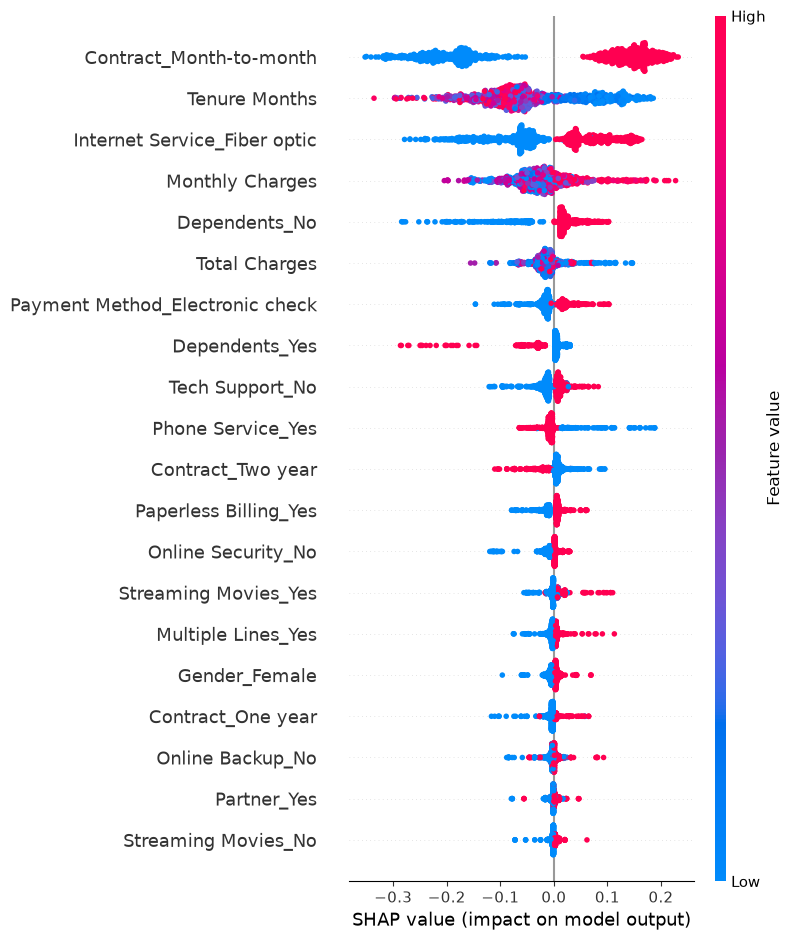

In [75]:
shap.summary_plot(
    shap_values_churn,
    x_test_trans,
    feature_names=feature_importance['names']
)

## Model Monitoring

In [76]:
def computePSI(train_data:pd.Series,production_data:pd.Series, bins:int = 10): 
  if pd.api.types.is_numeric_dtype(train_data): 
    bins = np.quantile(
      train_data, 
      np.linspace(0,1,bins + 1)
    )
    bins = np.unique(bins)
    
    if len(bins) < 2: 
      return np.nan
    
    train_dist = pd.cut(train_data, bins=bins, include_lowest=True)
    production_dist= pd.cut(production_data, bins=bins, include_lowest=True)
    
    train_dist = train_dist.value_counts(normalize=True, sort=False)
    #print("Training bins\n", train_dist)
    production_dist = production_dist.value_counts(normalize=True, sort=False)
    #print("Production bins\n", production_dist)
  else: 
    categories = set(list(train_data.unique()) + list(production_data.unique()))
    #print(f'Categories in {train_data.name}\n : {categories}')
    train_dist = train_data.value_counts(normalize=True).reindex(index=categories, fill_value=0)
    production_dist = production_data.value_counts(normalize=True).reindex(index=categories, fill_value=0)
  
  train_dist = train_dist.clip(lower=1e-6)
  production_dist = production_dist.clip(lower=1e-6)
  
  psi = ((train_dist - production_dist) * np.log(train_dist / production_dist)).sum()
  
  return psi.round(3)
  
  
  

In [77]:
X_test.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges'],
      dtype='str')

In [78]:
psi_result = {}
for col in X_train.columns: 
  psi_result[col] = computePSI(X_train[col], X_test[col])
psi_ps = pd.Series(psi_result).sort_values(ascending=False)
psi_ps

Tenure Months        0.015
Total Charges        0.004
Partner              0.003
Payment Method       0.003
Monthly Charges      0.003
Multiple Lines       0.002
Tech Support         0.001
Dependents           0.001
Gender               0.000
Senior Citizen       0.000
Phone Service        0.000
Device Protection    0.000
Online Backup        0.000
Online Security      0.000
Internet Service     0.000
Contract             0.000
Streaming Movies     0.000
Streaming TV         0.000
Paperless Billing    0.000
dtype: float64

In [79]:
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [80]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=20,
        random_state=42,
        class_weight="balanced",

    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

